#### Custom Project for CS44670

- Author: Caleb Sellinger
- Date: 7.20.2026
- Dataset: Global Semiconductor Industry 2010-2026
- Link to dataset: [Kaggle](https://www.kaggle.com/datasets/sergionefedov/global-semiconductor-industry-2010-2026/data)
- Target: monthly_wafer_capacity

## A. Prepare the Project Environment (.venv/)

- Open **only one project in VS Code at a time**.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## Section 1. Project Setup and Imports

In [8]:
from importlib.metadata import version
import logging
import platform
from typing import Final

from datafun_toolkit.logger import get_logger, log_header
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

LOG: logging.Logger = get_logger(__name__, level="INFO")
log_header(LOG, "Custom Project: Environment Setup")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-20 17:01:23 | INFO | __main__ | === RUN START ===
2026-07-20 17:01:23 | INFO | __main__ | project=Custom Project: Environment Setup
2026-07-20 17:01:23 | INFO | __main__ | repo_dir=CS44670-Module-3
2026-07-20 17:01:23 | INFO | __main__ | python=3.14.6
2026-07-20 17:01:23 | INFO | __main__ | os=Windows 11
2026-07-20 17:01:23 | INFO | __main__ | shell=powershell
2026-07-20 17:01:23 | INFO | __main__ | cwd=notebooks
2026-07-20 17:01:23 | INFO | __main__ | github_actions=False
2026-07-20 17:01:23 | INFO | __main__ | Confirming installation:
2026-07-20 17:01:23 | INFO | __main__ |   python:       3.14.6
2026-07-20 17:01:23 | INFO | __main__ |   pandas:       3.0.3
2026-07-20 17:01:23 | INFO | __main__ |   numpy:        2.5.1
2026-07-20 17:01:23 | INFO | __main__ |   scikit-learn: 1.9.0
2026-07-20 17:01:23 | INFO | __main__ |   matplotlib:   3.11.0


## Section 2. Load the Data

In [9]:
LOG.info("Loading datasets from KaggleHub...")

# Set the path to the file you'd like to load
file_path1 = "fab_capacity.csv"
file_path2 = "ai_chip_market.csv"

# Load the latest version
fab = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "sergionefedov/global-semiconductor-industry-2010-2026",
    file_path1,
)

ship = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "sergionefedov/global-semiconductor-industry-2010-2026",
    file_path2,
)

LOG.info(f"Loaded datasets: {file_path1} and {file_path2}")
LOG.info(f"Loaded: {fab.shape[0]} rows and {fab.shape[1]} columns from {file_path1}")
LOG.info(f"Loaded: {ship.shape[0]} rows and {ship.shape[1]} columns from {file_path2}")
# LOG.info(f"\nColumns in {file_path1}: {list(fab.columns)}")
# LOG.info(f"\nColumns in {file_path2}: {list(ship.columns)}")

2026-07-20 17:01:23 | INFO | __main__ | Loading datasets from KaggleHub...
2026-07-20 17:01:23 | INFO | __main__ | Loaded datasets: fab_capacity.csv and ai_chip_market.csv
2026-07-20 17:01:23 | INFO | __main__ | Loaded: 313 rows and 7 columns from fab_capacity.csv
2026-07-20 17:01:23 | INFO | __main__ | Loaded: 120 rows and 11 columns from ai_chip_market.csv


## Section 3. Assess the Data

In [10]:
# === Section 3. Assess the Data ===

# CUSTOM: ANALYST CHOICE - the column you intend to predict.
# Naming it now to watch for features that would leak it.

INTENDED_TARGET: Final[str] = "monthly_wafer_capacity"
LOG.info(f"The intended target is '{INTENDED_TARGET}'.")
LOG.info("Any feature derived FROM the target would leak the answer. Avoid those.")


# Report facts an analyst needs to judge whether columns are useful.

# WHY: Missingness, type, and basic spread tell us whether a column can
# carry signal and whether it is populated enough to rely on.
# This code reports those facts; it does not decide which columns to keep.

LOG.info("Per-column completeness and type:")

n_rows: int = fab.shape[0]

for col in fab.columns:
    missing: int = int(fab[col].isna().sum())
    pct_present: float = 100.0 * (n_rows - missing) / n_rows
    LOG.info(
        f"  {col:20s} {str(fab[col].dtype):10s} present={pct_present:5.1f}%  missing={missing}"
    )

numeric_cols: list[str] = fab.select_dtypes(include="number").columns.tolist()
LOG.info("Numeric summary (for spread / outliers):")
LOG.debug(f"\n{fab[numeric_cols].describe()}")

fab.info()
print(fab.head(10))
print(fab.corr(numeric_only=True))
print(fab.describe())

2026-07-20 17:01:23 | INFO | __main__ | The intended target is 'monthly_wafer_capacity'.
2026-07-20 17:01:23 | INFO | __main__ | Any feature derived FROM the target would leak the answer. Avoid those.
2026-07-20 17:01:23 | INFO | __main__ | Per-column completeness and type:
2026-07-20 17:01:23 | INFO | __main__ |   year                 int64      present=100.0%  missing=0
2026-07-20 17:01:23 | INFO | __main__ |   company              str        present=100.0%  missing=0
2026-07-20 17:01:23 | INFO | __main__ |   country_iso3         str        present=100.0%  missing=0
2026-07-20 17:01:23 | INFO | __main__ |   process_node_nm      int64      present=100.0%  missing=0
2026-07-20 17:01:23 | INFO | __main__ |   fab_type             str        present=100.0%  missing=0
2026-07-20 17:01:23 | INFO | __main__ |   monthly_wafer_capacity int64      present=100.0%  missing=0
2026-07-20 17:01:23 | INFO | __main__ |   fab_started_year     int64      present=100.0%  missing=0
2026-07-20 17:01:23 | I

<class 'pandas.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   year                    313 non-null    int64
 1   company                 313 non-null    str  
 2   country_iso3            313 non-null    str  
 3   process_node_nm         313 non-null    int64
 4   fab_type                313 non-null    str  
 5   monthly_wafer_capacity  313 non-null    int64
 6   fab_started_year        313 non-null    int64
dtypes: int64(4), str(3)
memory usage: 17.2 KB
   year company country_iso3  process_node_nm       fab_type  monthly_wafer_capacity  fab_started_year
0  2022    TSMC          TWN                3  logic_leading                       0              2022
1  2023    TSMC          TWN                3  logic_leading                   38445              2022
2  2024    TSMC          TWN                3  logic_leading                   80106        

## Section 4. Construct Features

2026-07-20 17:01:23 | INFO | __main__ | Constructing features (vectorized, none are derived from the target)
2026-07-20 17:01:23 | INFO | __main__ | Added features: ['fab_size', 'process_node_category']


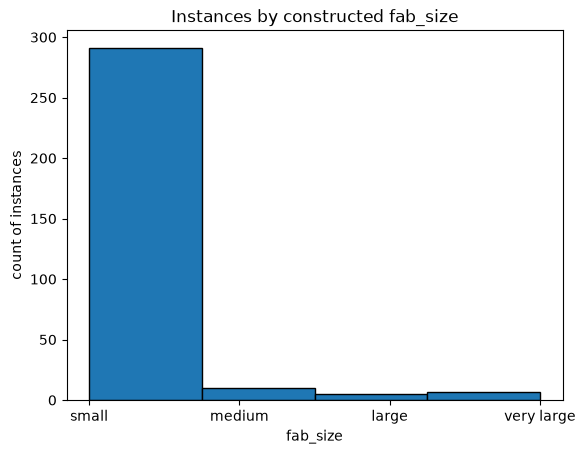

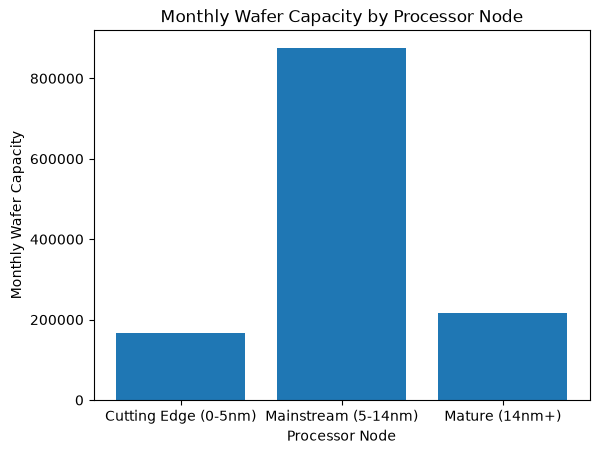

In [11]:
# === Section 4. Construct Features ===

"""Derive new features from existing columns (vectorized).

WHY: New inputs can make a real pattern easier for a model to use.
These operate on whole columns at once (no Python loop).
None of them is built from the intended target, so they cannot leak it.

Built here:
- bill_ratio: bill_length_mm / bill_depth_mm  (shape, unitless)
- flipper_cm: flipper_length_mm / 10            (rescaled)
- age_group: a category from age    (binned)

"""
LOG.info("Constructing features (vectorized, none are derived from the target)")

# Categorical feature via binning monthly_wafer_capacity
df_feat: pd.DataFrame = fab.copy()
wafer_cap_min = fab["monthly_wafer_capacity"].min() - 1
wafer_cap_max = fab["monthly_wafer_capacity"].max() + 1

df_feat["fab_size"] = pd.cut(
    df_feat["monthly_wafer_capacity"],
    bins=[
        wafer_cap_min,
        wafer_cap_max / 4,
        wafer_cap_max / 2,
        3 * wafer_cap_max / 4,
        wafer_cap_max,
    ],
    labels=["small", "medium", "large", "very large"],
)

# Categorical feature for binning process_node_nm
pnode_min = fab["process_node_nm"].min() - 1
pnode_max = fab["process_node_nm"].max() + 1

df_feat["process_node_category"] = pd.cut(
    df_feat["process_node_nm"],
    bins=[pnode_min, 5, 14, pnode_max],
    labels=["Cutting Edge (0-5nm)", "Mainstream (5-14nm)", "Mature (14nm+)"],
)

new_cols: list[str] = ["fab_size", "process_node_category"]

LOG.info(f"Added features: {new_cols}")

LOG.debug("Sample of constructed features:")
LOG.debug(
    f"\n{df_feat[['monthly_wafer_capacity', 'process_node_category', *new_cols]].head()}"
)

# Show the new categorical feature.
# Visualize in every project.

plt.figure()
plt.hist(df_feat["fab_size"], bins=4, edgecolor="black")
plt.title("Instances by constructed fab_size")
plt.xlabel("fab_size")
plt.ylabel("count of instances")
plt.show()

# Plot for monthly_wafer_capacity by processor_node_nm
plt.figure()
plt.bar(df_feat["process_node_category"], df_feat["monthly_wafer_capacity"])
plt.title("Monthly Wafer Capacity by Processor Node")
plt.xlabel("Processor Node")
plt.ylabel("Monthly Wafer Capacity")
plt.show()

## Section 5. Classification

test

In [12]:
## === Section 5. Train a Classifier ===

# Adding new feature column for company: TSMC, Intel, and Others
df_feat['company_classification'] = df_feat['company'].apply(
    lambda x: 'TSMC' if x == 'TSMC' else ('Intel' if x == 'Intel' else 'Others')
)

CLASSIFICATION_TARGET: Final[str] = "company_classification"
classifcation_cols = ["monthly_wafer_capacity", "process_node_nm"]

df_feat = df_feat.dropna(subset=classifcation_cols)

RANDOM_STATE: Final[int] = 42
X: pd.DataFrame = df_feat[classifcation_cols]
y: pd.Series = df_feat[CLASSIFICATION_TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
# model = svm.SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE)

model.fit(X_train, y_train)

2026-07-20 17:01:24 | INFO | __main__ | Train instances: 250
2026-07-20 17:01:24 | INFO | __main__ | Test instances: 63


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

2026-07-20 17:01:24 | INFO | __main__ | Test accuracy: 0.841
2026-07-20 17:01:24 | INFO | __main__ | Per-class precision / recall / F1:
2026-07-20 17:01:24 | INFO | __main__ | 
              precision    recall  f1-score   support

       Intel       0.58      0.88      0.70         8
      Others       0.88      0.88      0.88        43
        TSMC       1.00      0.67      0.80        12

    accuracy                           0.84        63
   macro avg       0.82      0.81      0.79        63
weighted avg       0.87      0.84      0.84        63

2026-07-20 17:01:24 | INFO | __main__ | Showing confusion matrix (rows = actual, cols = predicted)


<Figure size 640x480 with 0 Axes>

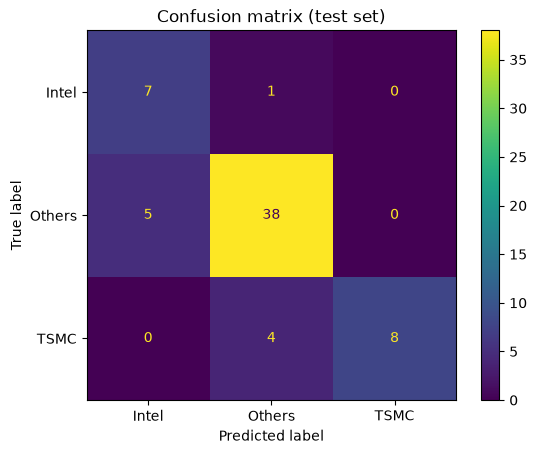

In [13]:
y_pred: np.ndarray = model.predict(X_test)

# The built in sklearn accuracy_score() function
# returns a numpy Float,
# which is not the same as a native Python float.
# call float() to convert it to a native Python float for better compatibility with other code and libraries.
test_acc: float = float(accuracy_score(y_test, y_pred))
LOG.info(f"Test accuracy: {test_acc:.3f}")

LOG.info("Per-class precision / recall / F1:")
LOG.info(f"\n{classification_report(y_test, y_pred)}")

LOG.info("Showing confusion matrix (rows = actual, cols = predicted)")

# start a figure
plt.figure()

# create the confusion matrix display
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

# set the title
plt.title("Confusion matrix (test set)")

# show the plot
plt.show()

2026-07-20 17:01:24 | INFO | __main__ |   depth= 1  train=0.684  test=0.683
2026-07-20 17:01:24 | INFO | __main__ |   depth= 2  train=0.720  test=0.730
2026-07-20 17:01:24 | INFO | __main__ |   depth= 3  train=0.816  test=0.841
2026-07-20 17:01:24 | INFO | __main__ |   depth= 4  train=0.880  test=0.873
2026-07-20 17:01:24 | INFO | __main__ |   depth= 5  train=0.896  test=0.841
2026-07-20 17:01:24 | INFO | __main__ |   depth= 6  train=0.920  test=0.825
2026-07-20 17:01:24 | INFO | __main__ |   depth= 7  train=0.932  test=0.794
2026-07-20 17:01:24 | INFO | __main__ |   depth= 8  train=0.944  test=0.794
2026-07-20 17:01:24 | INFO | __main__ |   depth= 9  train=0.956  test=0.778
2026-07-20 17:01:24 | INFO | __main__ |   depth=10  train=0.960  test=0.778
2026-07-20 17:01:24 | INFO | __main__ |   depth=11  train=0.964  test=0.778
2026-07-20 17:01:24 | INFO | __main__ |   depth=12  train=0.972  test=0.778


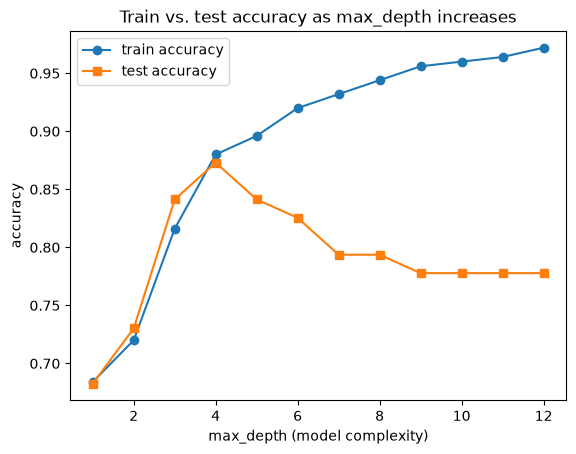

In [14]:
MAX_SWEEP: Final[int] = 12

# Declare lists to hold the depths and corresponding train/test scores.
depths: list[int] = list(range(1, MAX_SWEEP + 1))
train_scores: list[float] = []
test_scores: list[float] = []

for depth in depths:
    # create and fit a DecisionTreeClassifier with the current depth and random_state
    m = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)

    acc_score_train = accuracy_score(y_train, m.predict(X_train))
    acc_score_test = accuracy_score(y_test, m.predict(X_test))

    # Use float() to convert from numpy Float to native Python float for better compatibility with other code and libraries.
    train_scores.append(float(acc_score_train))
    test_scores.append(float(acc_score_test))

    LOG.info(
        f"  depth={depth:2d}  train={train_scores[-1]:.3f}  test={test_scores[-1]:.3f}"
    )

# start a new figure
plt.figure()

# plot the train and test scores against the depths
plt.plot(depths, train_scores, marker="o", label="train accuracy")
plt.plot(depths, test_scores, marker="s", label="test accuracy")

# label the axes and add a title and legend
plt.xlabel("max_depth (model complexity)")
plt.ylabel("accuracy")
plt.title("Train vs. test accuracy as max_depth increases")
plt.legend()

# show the plot
plt.show()